<a href="https://colab.research.google.com/github/444112029012/phishing-detection-project/blob/main/colab/%E5%A0%86%E7%96%8A%E6%95%88%E8%83%BD%E9%A9%97%E8%AD%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install tensorflow
!pip install joblib

In [ ]:
import joblib
from xgboost import XGBClassifier
xgb_url_model = XGBClassifier()
xgb_url_model.load_model('/content/optuna_xgb_url_final.json')
xgb_html_model = XGBClassifier()
xgb_html_model.load_model('/content/optuna_xgb_html_final.json')
xgb_ai_model = XGBClassifier()
xgb_ai_model.load_model('/content/optuna_xgb_ai_final.json')
meta_model = joblib.load('/content/meta_logistic_final.pkl')

In [ ]:
import pandas as pd
df = pd.read_csv('/content/meta_test.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10918 entries, 0 to 10917
Data columns (total 78 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   url                                10918 non-null  object 
 1   target                             10918 non-null  int64  
 2   length_url                         10918 non-null  int64  
 3   length_hostname                    10918 non-null  int64  
 4   ip                                 10918 non-null  int64  
 5   nb_dots                            10918 non-null  int64  
 6   nb_hyphens                         10918 non-null  int64  
 7   nb_at                              10918 non-null  int64  
 8   nb_qm                              10918 non-null  int64  
 9   nb_and                             10918 non-null  int64  
 10  nb_or                              10918 non-null  int64  
 11  nb_eq                              10918 non-null  int

In [ ]:
print("目前 target 數量分佈：")
print(df['target'].value_counts())

目前 target 數量分佈：
target
1    9620
0    1298
Name: count, dtype: int64


In [ ]:
df_con = df.copy()

In [ ]:
url = df_con[['length_url', 'length_hostname', 'ip', 'nb_dots',
       'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq',
       'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star',
       'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space',
       'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token',
       'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port',
       'tld_in_path', 'tld_in_subdomain', 'nb_subdomains',
       'abnormal_subdomain', 'prefix_suffix', 'path_extension',
       'length_words_raw', 'char_repeat', 'shortest_word_host',
       'shortest_word_path', 'longest_words_raw', 'longest_word_host',
       'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path'
    ]]
html = df_con[[
        'phish_hints', 'domain_in_brand', 'nb_hyperlinks', 'ratio_intHyperlinks',
        'ratio_extHyperlinks', 'ratio_extRedirection', 'ratio_extErrors',
        'external_favicon', 'links_in_tags', 'ratio_extMedia', 'safe_anchor',
        'empty_title', 'domain_in_title', 'domain_with_copyright',
        'has_meta_refresh', 'has_js_redirect'
        ]]
ai = df_con[['creates_urgency', 'uses_threats', 'requests_sensitive_info',
            'offers_unrealistic_rewards', 'has_spelling_grammar_errors',
            'impersonated_brand', 'has_valid_copyright_year',
            'is_content_login_focused', 'has_rich_navigation',
            'has_physical_address', 'has_phone_number',
            'content_consistency_score', 'language_professionalism_score',
            'overall_phishing_likelihood_score', 'text_length'
            ]]
y_true = df_con['target']

In [ ]:
bool_col = ['creates_urgency', 'uses_threats', 'requests_sensitive_info',
            'offers_unrealistic_rewards', 'has_spelling_grammar_errors',
            'has_valid_copyright_year', 'is_content_login_focused',
            'has_rich_navigation', 'has_physical_address', 'has_phone_number']
ai[bool_col] = ai[bool_col].astype(int)
ai['impersonated_brand'] = [1 if k else 0 for k in ai['impersonated_brand'].notnull()]

/tmp/ipykernel_992/119799368.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai[bool_col] = ai[bool_col].astype(int)
/tmp/ipykernel_992/119799368.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai['impersonated_brand'] = [1 if k else 0 for k in ai['impersonated_brand'].notnull()]


In [ ]:
url.info()
html.info()
ai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10918 entries, 0 to 10917
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   length_url          10918 non-null  int64  
 1   length_hostname     10918 non-null  int64  
 2   ip                  10918 non-null  int64  
 3   nb_dots             10918 non-null  int64  
 4   nb_hyphens          10918 non-null  int64  
 5   nb_at               10918 non-null  int64  
 6   nb_qm               10918 non-null  int64  
 7   nb_and              10918 non-null  int64  
 8   nb_or               10918 non-null  int64  
 9   nb_eq               10918 non-null  int64  
 10  nb_underscore       10918 non-null  int64  
 11  nb_tilde            10918 non-null  int64  
 12  nb_percent          10918 non-null  int64  
 13  nb_slash            10918 non-null  int64  
 14  nb_star             10918 non-null  int64  
 15  nb_colon            10918 non-null  int64  
 16  nb_c

In [ ]:
y_pred_proba_url = xgb_url_model.predict_proba(url)[:, 1]
y_pred_proba_html = xgb_html_model.predict_proba(html)[:, 1]
y_pred_proba_ai = xgb_ai_model.predict_proba(ai)[:, 1]

In [ ]:
#查看權重 (係數)
print("權重 (Coefficients):")
print(meta_model.coef_)

#查看截距 (偏差值)
print("\n截距 (Intercept):")
print(meta_model.intercept_)

權重 (Coefficients):
[[10.73311249  2.24048876  0.2625752 ]]

截距 (Intercept):
[-7.86149198]


In [ ]:
print(sum(y_true==0))
print(sum(y_true==1))

1298
9620


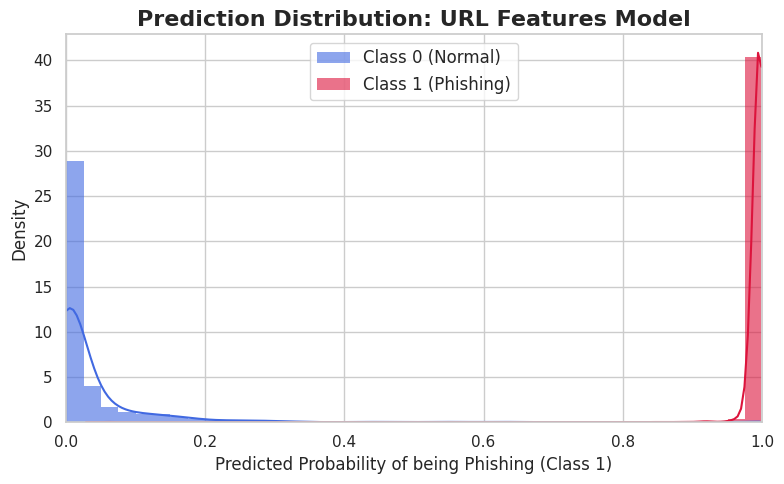

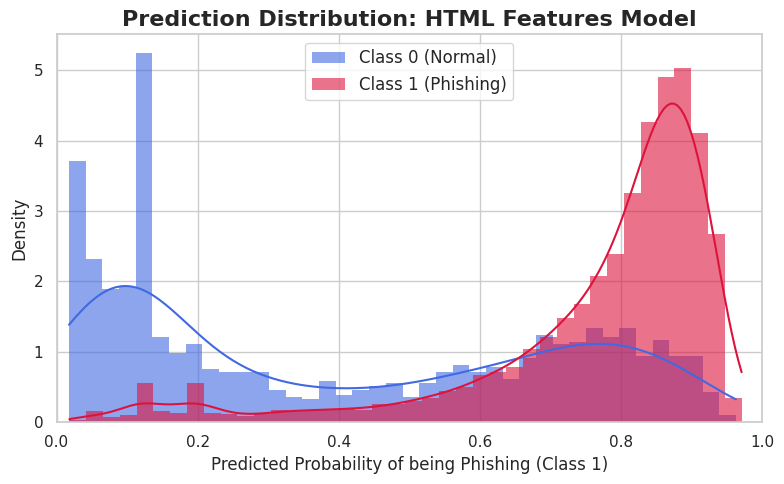

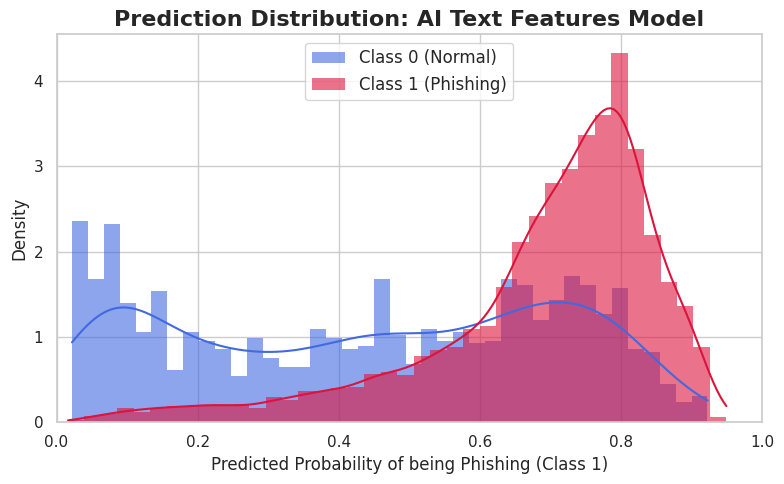

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定圖表風格，讓報告看起來更專業
sns.set_theme(style="whitegrid")

# 建立一個專門畫機率分布圖的函式
def plot_model_distribution(y_true, y_pred_proba, model_name):
    plt.figure(figsize=(8, 5)) # 設定單張圖的大小

    # 繪製 Class 0 (正常網站) 的機率分布 (藍色)
    sns.histplot(y_pred_proba[y_true == 0], color="royalblue", label="Class 0 (Normal)",
                 kde=True, stat="density", linewidth=0, alpha=0.6, bins=40)

    # 繪製 Class 1 (釣魚網站) 的機率分布 (紅色)
    sns.histplot(y_pred_proba[y_true == 1], color="crimson", label="Class 1 (Phishing)",
                 kde=True, stat="density", linewidth=0, alpha=0.6, bins=40)

    # 設定標題與軸標籤
    plt.title(f'Prediction Distribution: {model_name} Model', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Probability of being Phishing (Class 1)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.xlim(0, 1) # 機率範圍固定 0 到 1

    # 顯示圖例
    plt.legend(fontsize=12, loc='upper center')
    plt.tight_layout()

    # 呈現圖表
    plt.show()

# ==========================================
# 開始分別畫出三張圖
# ==========================================

# 1. 繪製 URL 模型的分布
plot_model_distribution(y_true, y_pred_proba_url, "URL Features")

# 2. 繪製 HTML 模型的分布
plot_model_distribution(y_true, y_pred_proba_html, "HTML Features")

# 3. 繪製 AI 文本特徵模型的分布
plot_model_distribution(y_true, y_pred_proba_ai, "AI Text Features")

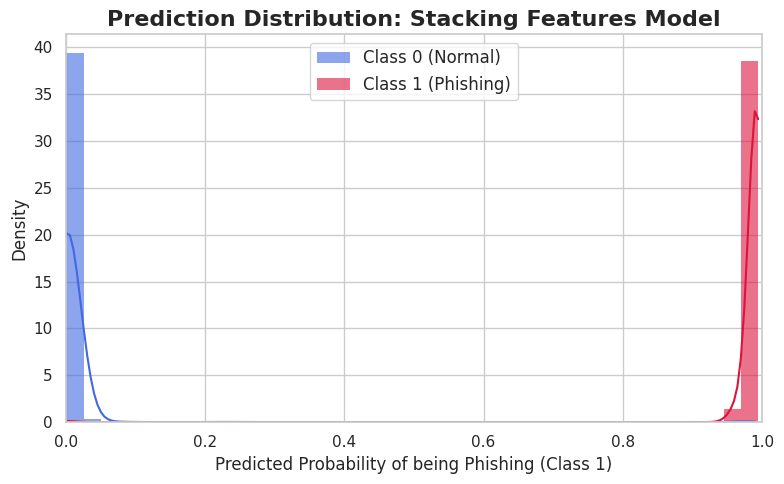

In [ ]:
import numpy as np
meta = np.c_[y_pred_proba_url, y_pred_proba_html, y_pred_proba_ai]
y_pred_proba_meta = meta_model.predict_proba(meta)[:, 1]
plot_model_distribution(y_true, y_pred_proba_meta, "Stacking Features")

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def get_model_metrics(y_true, y_pred_proba, model_name, threshold=0.5):
    # 1. 計算 ROC AUC (這是不受 threshold 影響的指標，只看模型排序能力)
    auc = roc_auc_score(y_true, y_pred_proba)

    # 2. 根據門檻 (threshold) 將機率轉換成 0 或 1 的硬標籤
    y_pred_label = (y_pred_proba >= threshold).astype(int)

    # 3. 計算各項分類指標
    acc = accuracy_score(y_true, y_pred_label)
    prec = precision_score(y_true, y_pred_label, zero_division=0)
    rec = recall_score(y_true, y_pred_label, zero_division=0)
    f1 = f1_score(y_true, y_pred_label, zero_division=0)

    # 回傳成字典方便整理
    return {
        'Model': model_name,
        'ROC AUC': auc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

# ==========================================
# 收集三個模型的指標並轉換成表格
# ==========================================
metrics_list = []
metrics_list.append(get_model_metrics(y_true, y_pred_proba_url, 'URL Model'))
metrics_list.append(get_model_metrics(y_true, y_pred_proba_html, 'HTML Model'))
metrics_list.append(get_model_metrics(y_true, y_pred_proba_ai, 'AI Text Model'))
metrics_list.append(get_model_metrics(y_true, y_pred_proba_meta, 'Meta Model'))
# 顯示成漂亮的 DataFrame
df_metrics = pd.DataFrame(metrics_list)
# 將數字格式化到小數點後四位
display(df_metrics.style.format({
    'ROC AUC': '{:.4f}', 'Accuracy': '{:.4f}',
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-Score': '{:.4f}'
}))

,Model,ROC AUC,Accuracy,Precision,Recall,F1-Score
0,URL Model,0.9981,0.9947,0.9985,0.9954,0.9970
1,HTML Model,0.8384,0.8710,0.9427,0.9088,0.9255
2,AI Text Model,0.7747,0.8333,0.9339,0.8726,0.9022
3,Meta Model,0.9987,0.9945,0.9989,0.9949,0.9969


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss
from scipy.stats import ks_2samp

def evaluate_separation(y_true, y_pred_proba, model_name):
    # 確保格式正確
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)

    # 1. 計算 K-S Statistic (分化距離，數值越大越好)
    # 將機率分為 Class 0 和 Class 1
    proba_class_0 = y_pred_proba[y_true == 0]
    proba_class_1 = y_pred_proba[y_true == 1]

    # 使用 scipy 計算 K-S 統計量
    ks_stat, _ = ks_2samp(proba_class_0, proba_class_1)
    ks_score = ks_stat * 100 # 轉換為百分比 (0~100)

    # 2. 計算猶豫區間比例 (落在 0.4 ~ 0.6 的資料比例，數值越低越好)
    ambiguous_count = np.sum((y_pred_proba >= 0.4) & (y_pred_proba <= 0.6))
    ambiguity_ratio = (ambiguous_count / len(y_pred_proba)) * 100

    # 3. 計算 Brier Score (機率均方誤差，數值越低越好)
    brier = brier_score_loss(y_true, y_pred_proba)

    # 4. 計算高自信區間 (大於0.9 或 小於0.1 的比例，數值越高越好)
    confident_count = np.sum((y_pred_proba >= 0.9) | (y_pred_proba <= 0.1))
    confidence_ratio = (confident_count / len(y_pred_proba)) * 100

    return {
        'Model': model_name,
        'K-S Score (↑)': ks_score,
        'Brier Score (↓)': brier,
        'Ambiguity Ratio (%) (↓)': ambiguity_ratio,
        'High Confidence Ratio (%) (↑)': confidence_ratio
    }

# ==========================================
# 收集四個模型的分化指標 (請替換成你測試集的預測機率變數)
# ==========================================
sep_metrics = []
# 使用meta_test測試集
sep_metrics.append(evaluate_separation(y_true, y_pred_proba_url, 'URL Model'))
sep_metrics.append(evaluate_separation(y_true, y_pred_proba_html, 'HTML Model'))
sep_metrics.append(evaluate_separation(y_true, y_pred_proba_ai, 'AI Text Model'))
sep_metrics.append(evaluate_separation(y_true, y_pred_proba_meta, 'Meta (Stacked) Model'))

# 顯示成 DataFrame
df_sep = pd.DataFrame(sep_metrics)
display(df_sep.style.format({
    'K-S Score (↑)': '{:.2f}',
    'Brier Score (↓)': '{:.4f}',
    'Ambiguity Ratio (%) (↓)': '{:.2f}%',
    'High Confidence Ratio (%) (↑)': '{:.2f}%'
}))

,Model,K-S Score (↑),Brier Score (↓),Ambiguity Ratio (%) (↓),High Confidence Ratio (%) (↑)
0,URL Model,99.00,0.0043,0.17%,98.13%
1,HTML Model,53.09,0.1100,6.92%,18.39%
2,AI Text Model,43.09,0.1415,14.63%,4.77%
3,Meta (Stacked) Model,98.98,0.0050,0.06%,99.69%
